In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

# Plot style
sns.set(style="whitegrid")

# Load the dataset
import pandas as pd


df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [4]:
# Number of unique values in each column
print(df.nunique())

# Value counts for categorical variables

for col in ["Gender","Occupation","BMI Category","Sleep Disorder"]:
    print("\n",col)
    print(df[col].value_counts())

Person ID                  374
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 4
Blood Pressure              25
Heart Rate                  19
Daily Steps                 20
Sleep Disorder               2
dtype: int64

 Gender
Gender
Male      189
Female    185
Name: count, dtype: int64

 Occupation
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

 BMI Category
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

 Sleep Disorder
Sleep Disord

----------
----------
----------
----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
m

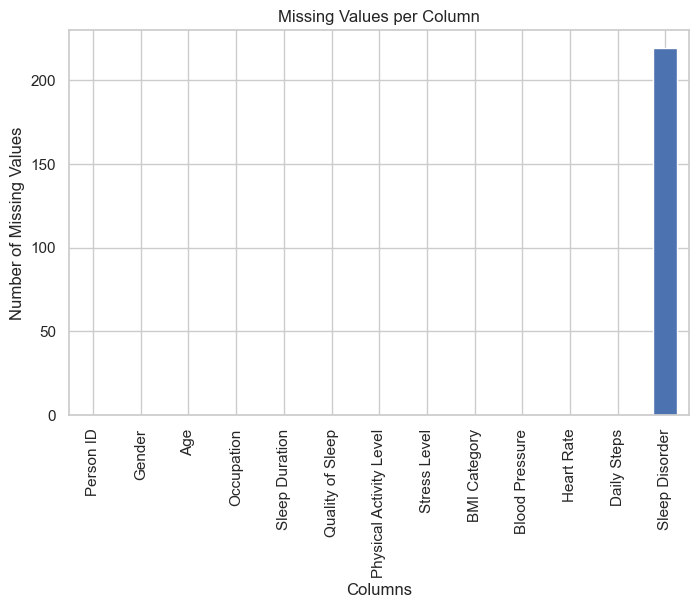

Initial Statistics of the Dataset:
         Person ID Gender         Age Occupation  Sleep Duration  \
count   374.000000    374  374.000000        374      374.000000   
unique         NaN      2         NaN         11             NaN   
top            NaN   Male         NaN      Nurse             NaN   
freq           NaN    189         NaN         73             NaN   
mean    187.500000    NaN   42.184492        NaN        7.132086   
std     108.108742    NaN    8.673133        NaN        0.795657   
min       1.000000    NaN   27.000000        NaN        5.800000   
25%      94.250000    NaN   35.250000        NaN        6.400000   
50%     187.500000    NaN   43.000000        NaN        7.200000   
75%     280.750000    NaN   50.000000        NaN        7.800000   
max     374.000000    NaN   59.000000        NaN        8.500000   

        Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
count         374.000000               374.000000    374.000000     

In [5]:
# Inspect the Data
# Display first 5 rows
df.head()
print("-"*10)
# Display last 5 rows
df.tail()
print("-"*10)
# Dataset dimensions
df.shape
print("-"*10)
# Column names
df.columns
print("-"*10)
# Data types and missing values
df.info()
print("-"*10)
# Statistical summary
df.describe()
print("-"*10)
# Check missing values
df.isnull().sum()
print("-"*10)
# Check duplicated rows
df.duplicated().sum()

missing = df.isnull().sum()

missing.plot(kind='bar', figsize=(8,5))

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.show()

# Show initial statistics of the dataset
print("Initial Statistics of the Dataset:")
print(df.describe(include='all'))

*The dataset contains no missing values in most variables. 
Missing values were only observed in the Sleep Disorder column (219 records),
representing participants without diagnosed sleep disorders. 
These missing values were replaced with "None" during data preprocessing to preserve all observations for subsequent analyses.*


Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


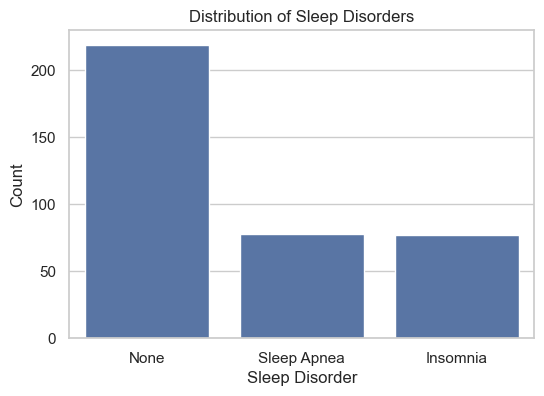

In [6]:
# Exploratory Data Analysis (EDA)

#Distribution of Sleep Disorders
import matplotlib.pyplot as plt
import seaborn as sns

# Replace missing values with "None"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Check the distribution of sleep disorders
print(df["Sleep Disorder"].value_counts())

# Plot the distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sleep Disorder")

plt.title("Distribution of Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")

plt.show()

*Most participants (219 out of 374) did not report any sleep disorder, 
while insomnia (77 participants) and sleep apnea (78 participants) occurred in similar proportions. 
This indicates that the dataset is dominated by healthy individuals, 
with nearly balanced representation of the two major sleep disorders.*

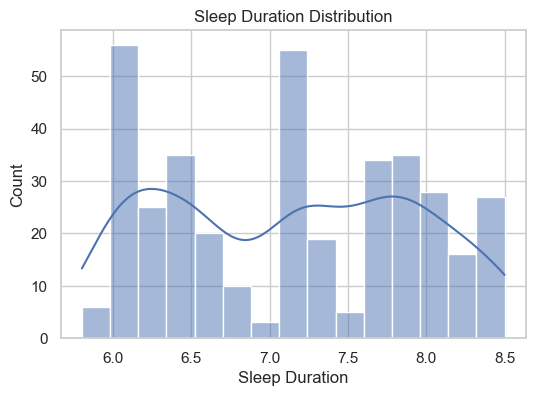

In [7]:
#Sleep Duration Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["Sleep Duration"], bins=15, kde=True)

plt.title("Sleep Duration Distribution")

plt.show()

*Sleep duration among participants ranged from approximately 5.8 to 8.5 hours,
with most individuals sleeping between 6 and 8 hours. 
The distribution suggests that the majority of participants achieved sleep durations close to the recommended range for adults.*

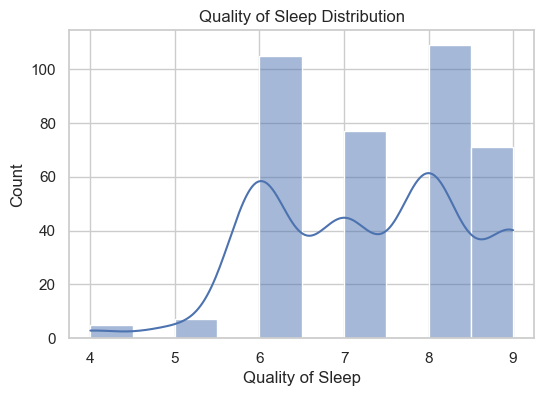

In [8]:
# Sleep Quality Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["Quality of Sleep"], bins=10, kde=True)

plt.title("Quality of Sleep Distribution")

plt.show()

*Most participants reported moderate to high sleep quality, 
with ratings primarily between 6 and 9. Very low sleep quality scores were uncommon, 
indicating that the overall study population generally experienced satisfactory sleep quality.*

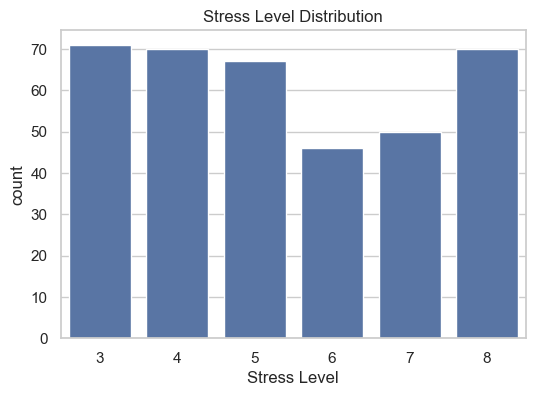

In [9]:
# Stress Level Distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Stress Level")

plt.title("Stress Level Distribution")

plt.show()

*Stress levels ranged from 3 to 8, with a relatively balanced distribution across the different categories. 
Moderate stress levels were more common than extreme values, suggesting variability in perceived stress among participants.*

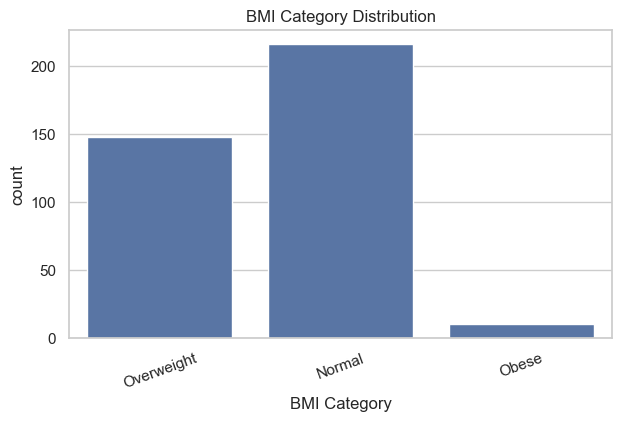

In [10]:
# BMI Categories
# Standardize BMI categories
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

plt.figure(figsize=(7,4))

sns.countplot(data=df, x="BMI Category")

plt.title("BMI Category Distribution")

plt.xticks(rotation=20)

plt.show()

Normal: This is the largest group in the dataset (216 individuals), meaning more than half of the population has a healthy weight.

Overweight: This is the second-largest group (148 individuals), which is a significant number for analysis.

Obese: This is the smallest group, with only 10 individuals.

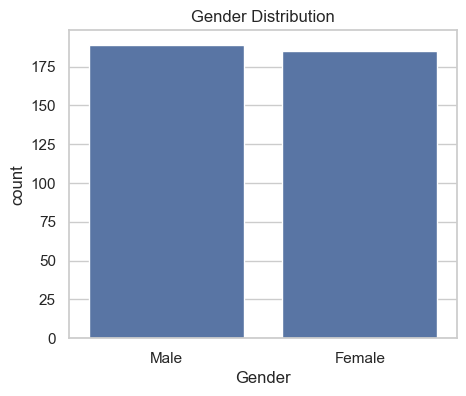

In [11]:
# Gender Distribution
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")

plt.show()

The dataset is highly balanced between genders, with a nearly equal number of Males (189) and Females (185).

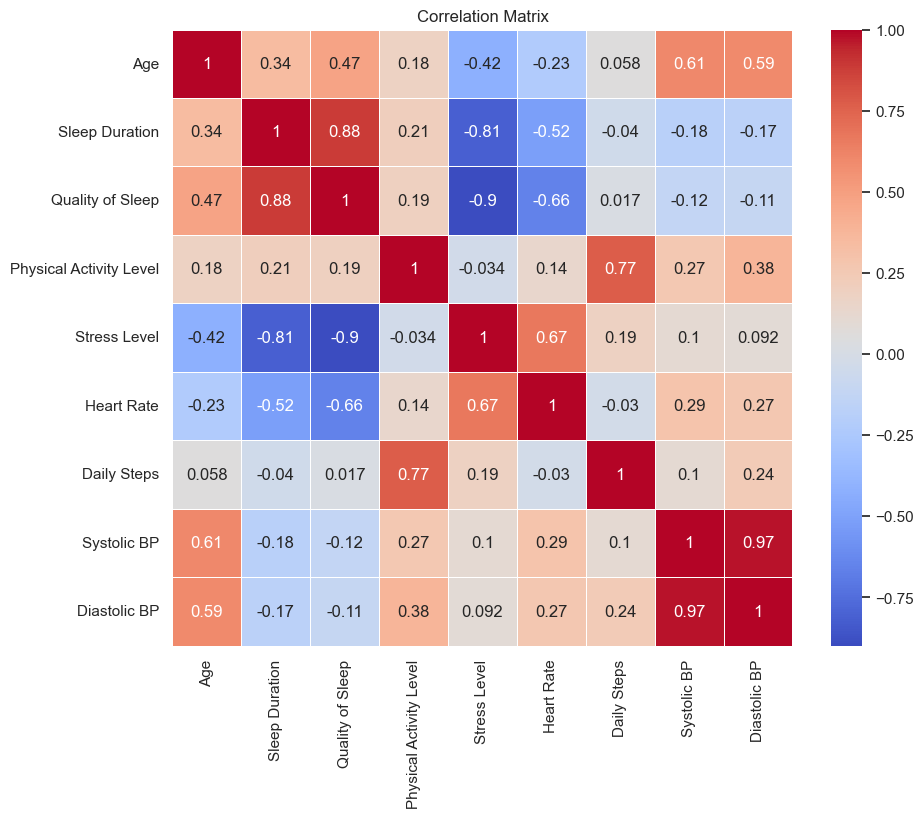

In [12]:
# Correlation Matrix
# Prepare the Data
df[["Systolic BP", "Diastolic BP"]] = df["Blood Pressure"].str.split("/", expand=True)

df["Systolic BP"] = df["Systolic BP"].astype(int)

df["Diastolic BP"] = df["Diastolic BP"].astype(int)

numeric_df = df.drop(columns=["Person ID"]).select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

Strong Positive Relationships (Red 📈):

Sleep Duration and Quality of Sleep (0.88): Longer sleep leads to much better sleep quality.
Physical Activity Level and Daily Steps (0.77): Higher physical activity strictly means more daily steps.
Systolic BP and Diastolic BP (0.97): They move together almost perfectly; when one rises, the other does too.

Strong Negative Relationships (Blue 📉)

Stress Level and Quality of Sleep (-0.9):* Higher stress drastically reduces sleep quality.
Stress Level and Sleep Duration (-0.81): High stress strongly reduces the total hours of sleep.

No Relationship (Grey ⚪):

Daily Steps and Quality of Sleep (0.017): Walking more steps does not have a direct impact on sleep quality in this data.

In [13]:
# Outlier Detection
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    outliers=((df[col]<lower)|(df[col]>upper)).sum()

    print(col,outliers)

Person ID 0
Age 0
Sleep Duration 0
Quality of Sleep 0
Physical Activity Level 0
Stress Level 0
Heart Rate 15
Daily Steps 0
Systolic BP 0
Diastolic BP 0


In [14]:

# check new columns
df.head()
# Check Missing Values Again
df.isnull().sum()
# Remove Duplicates (if any)
df = df.drop_duplicates()
# Final Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
 13  Systolic BP              374 non-null    int64  
 14  Diastolic BP             3

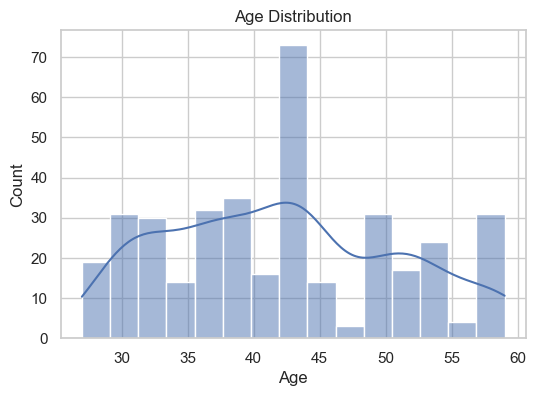

In [15]:
# Age Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution")

plt.show()

Age Range: The dataset includes adults ranging from 27 to 59 years old.

Peak Age Group: There is a very high concentration of individuals around the age of 42-44, making it the most dominant age group in the data.

Overall Spread: Outside of that main peak, the distribution is relatively well-spread across the 30s, 40s, and 50s, giving the model a good variety of working-age adults to learn from.

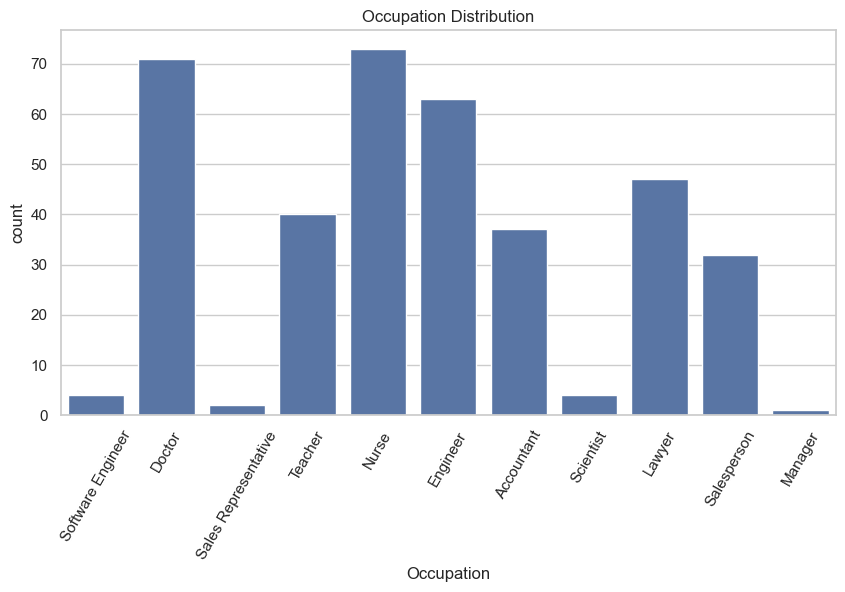

In [16]:
# Occupation Distribution
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Occupation")

plt.xticks(rotation=60)

plt.title("Occupation Distribution")

plt.show()


Top Occupations: Nurses (73) and Doctors (71) are the most common professions in the dataset, closely followed by Engineers (63).

Moderate Groups: Teachers, Accountants, Lawyers, and Salespersons form a solid, mid-sized representation.

Rare Occupations: Software Engineers, Sales Representatives, Scientists, and Managers have extremely low counts (under 5 each).